In [1]:
!pip install gymnasium numpy matplotlib pygame

Defaulting to user installation because normal site-packages is not writeable
  Using cached gymnasium-1.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached pygame-2.6.1-cp313-cp313-win_amd64.whl.metadata (13 kB)
  Using cached farama_notifications-0.0.6-py3-none-any.whl.metadata (729 bytes)
Using cached gymnasium-1.3.0-py3-none-any.whl (953 kB)
Using cached pygame-2.6.1-cp313-cp313-win_amd64.whl (10.6 MB)
Using cached farama_notifications-0.0.6-py3-none-any.whl (2.9 kB)

   ------------- -------------------------- 1/3 [pygame]
   ------------- -------------------------- 1/3 [pygame]
   ------------- -------------------------- 1/3 [pygame]
   ------------- -------------------------- 1/3 [pygame]
   ------------- -------------------------- 1/3 [pygame]
   ------------- -------------------------- 1/3 [pygame]
   ------------- -------------------------- 1/3 [pygame]
   ------------- -------------------------- 1/3 [pygame]
   ------------- -------------------------- 1/3 [pygame]
   ------

## 1. Install libraries

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pickle

## 2. Create the MountainCar environment

In [3]:
env = gym.make("MountainCar-v0")

print("Observation Space:", env.observation_space)
print("Action Space:", env.action_space)

Observation Space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Action Space: Discrete(3)


## 3. Understand the problem:- # 
Agent has to learn to: Move Left -->> Build Momentum -->> Move Right -->> Build more momentum -->> Reach the flag 🏁 

## 4. Check the state boundaries

In [4]:
print("State minimum:",env.observation_space.low)
print("State Maximum:",env.observation_space.high)

State minimum: [-1.2  -0.07]
State Maximum: [0.6  0.07]


## 5. Define discretization

In [5]:
POSITION_BINS = 20
VELOCITY_BINS = 20

position_bins = np.linspace(
    env.observation_space.low[0],
    env.observation_space.high[0],
    POSITION_BINS
)

velocity_bins = np.linspace(
    env.observation_space.low[1],
    env.observation_space.high[1],
    VELOCITY_BINS
)

## 6. Create a state discretization function

In [8]:
def discretize_state(state):
    position, velocity = state

    position_index = np.digitize(position, position_bins) - 1
    velocity_index = np.digitize(velocity, velocity_bins) - 1

    position_index = np.clip(position_index, 0, POSITION_BINS - 1)
    velocity_index = np.clip(velocity_index, 0, VELOCITY_BINS - 1)

    return position_index, velocity_index

In [9]:
state, info = env.reset()

print("Original state:", state)
print("Discretized state:", discretize_state(state))

Original state: [-0.5342301  0.       ]
Discretized state: (np.int64(7), np.int64(9))


## 7. Create the Q-table

In [10]:
q_table = np.zeros(
    (POSITION_BINS, VELOCITY_BINS, env.action_space.n)
)

print(q_table.shape)

(20, 20, 3)


## 8. Define Q-learning parameters

In [12]:
learning_rate = 0.1
discount_factor = 0.99

epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995

episodes = 10000

## 9. Implement ε-greedy action selection

In [13]:
def choose_action(state, epsilon):

    if np.random.random() < epsilon:
        return env.action_space.sample()

    position, velocity = state

    return np.argmax(q_table[position, velocity])

## 10. Implement Q-Learning

In [14]:
def update_q_table(state, action, reward, next_state):

    position, velocity = state
    next_position, next_velocity = next_state

    current_q = q_table[position, velocity, action]

    max_next_q = np.max(
        q_table[next_position, next_velocity]
    )

    new_q = current_q + learning_rate * (
        reward + discount_factor * max_next_q - current_q
    )

    q_table[position, velocity, action] = new_q

## 11. Training loop

In [15]:
rewards_per_episode = []
epsilon_values = []

for episode in range(episodes):

    state, info = env.reset()
    state = discretize_state(state)

    total_reward = 0

    terminated = False
    truncated = False

    while not (terminated or truncated):

        action = choose_action(state, epsilon)

        next_state, reward, terminated, truncated, info = env.step(action)

        next_state = discretize_state(next_state)

        update_q_table(
            state,
            action,
            reward,
            next_state
        )

        state = next_state

        total_reward += reward

    rewards_per_episode.append(total_reward)
    epsilon_values.append(epsilon)

    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )

    if (episode + 1) % 500 == 0:
        print(
            f"Episode: {episode + 1}, "
            f"Reward: {total_reward:.0f}, "
            f"Epsilon: {epsilon:.3f}"
        )

Episode: 500, Reward: -200, Epsilon: 0.082
Episode: 1000, Reward: -160, Epsilon: 0.010
Episode: 1500, Reward: -159, Epsilon: 0.010
Episode: 2000, Reward: -154, Epsilon: 0.010
Episode: 2500, Reward: -155, Epsilon: 0.010
Episode: 3000, Reward: -151, Epsilon: 0.010
Episode: 3500, Reward: -139, Epsilon: 0.010
Episode: 4000, Reward: -147, Epsilon: 0.010
Episode: 4500, Reward: -200, Epsilon: 0.010
Episode: 5000, Reward: -113, Epsilon: 0.010
Episode: 5500, Reward: -125, Epsilon: 0.010
Episode: 6000, Reward: -133, Epsilon: 0.010
Episode: 6500, Reward: -200, Epsilon: 0.010
Episode: 7000, Reward: -158, Epsilon: 0.010
Episode: 7500, Reward: -155, Epsilon: 0.010
Episode: 8000, Reward: -131, Epsilon: 0.010
Episode: 8500, Reward: -119, Epsilon: 0.010
Episode: 9000, Reward: -119, Epsilon: 0.010
Episode: 9500, Reward: -187, Epsilon: 0.010
Episode: 10000, Reward: -148, Epsilon: 0.010


## 13. Plot epsilon decay

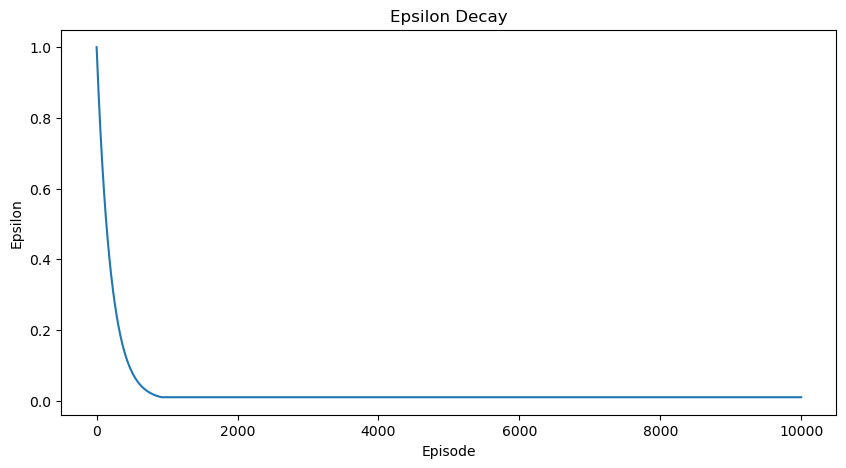

In [17]:
#Exploration -->> Exploration + Exploitaton -->> Mostly Exploitation
plt.figure(figsize=(10, 5))

plt.plot(epsilon_values)

plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.title("Epsilon Decay")

plt.show()

## 14. Evaluate the trained agent

In [18]:
evaluation_episodes = 10

evaluation_rewards = []

for episode in range(evaluation_episodes):

    state, info = env.reset()
    state = discretize_state(state)

    total_reward = 0

    terminated = False
    truncated = False

    while not (terminated or truncated):

        position, velocity = state

        action = np.argmax(
            q_table[position, velocity]
        )

        next_state, reward, terminated, truncated, info = env.step(action)

        state = discretize_state(next_state)

        total_reward += reward

    evaluation_rewards.append(total_reward)

    print(
        f"Episode {episode + 1}: "
        f"Reward = {total_reward}"
    )

Episode 1: Reward = -148.0
Episode 2: Reward = -144.0
Episode 3: Reward = -159.0
Episode 4: Reward = -141.0
Episode 5: Reward = -150.0
Episode 6: Reward = -200.0
Episode 7: Reward = -200.0
Episode 8: Reward = -149.0
Episode 9: Reward = -149.0
Episode 10: Reward = -152.0


## 16. Render the trained agent 🚗

In [19]:
render_env = gym.make(
    "MountainCar-v0",
    render_mode="human"
)

In [29]:
render_env = gym.make(
    "MountainCar-v0",
    render_mode="human"
)

state, info = render_env.reset()
state = discretize_state(state)

terminated = False
truncated = False

while not (terminated or truncated):

    position, velocity = state

    # Greedy action — no exploration
    action = np.argmax(q_table[position, velocity])

    next_state, reward, terminated, truncated, info = render_env.step(action)

    state = discretize_state(next_state)

render_env.close()